In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

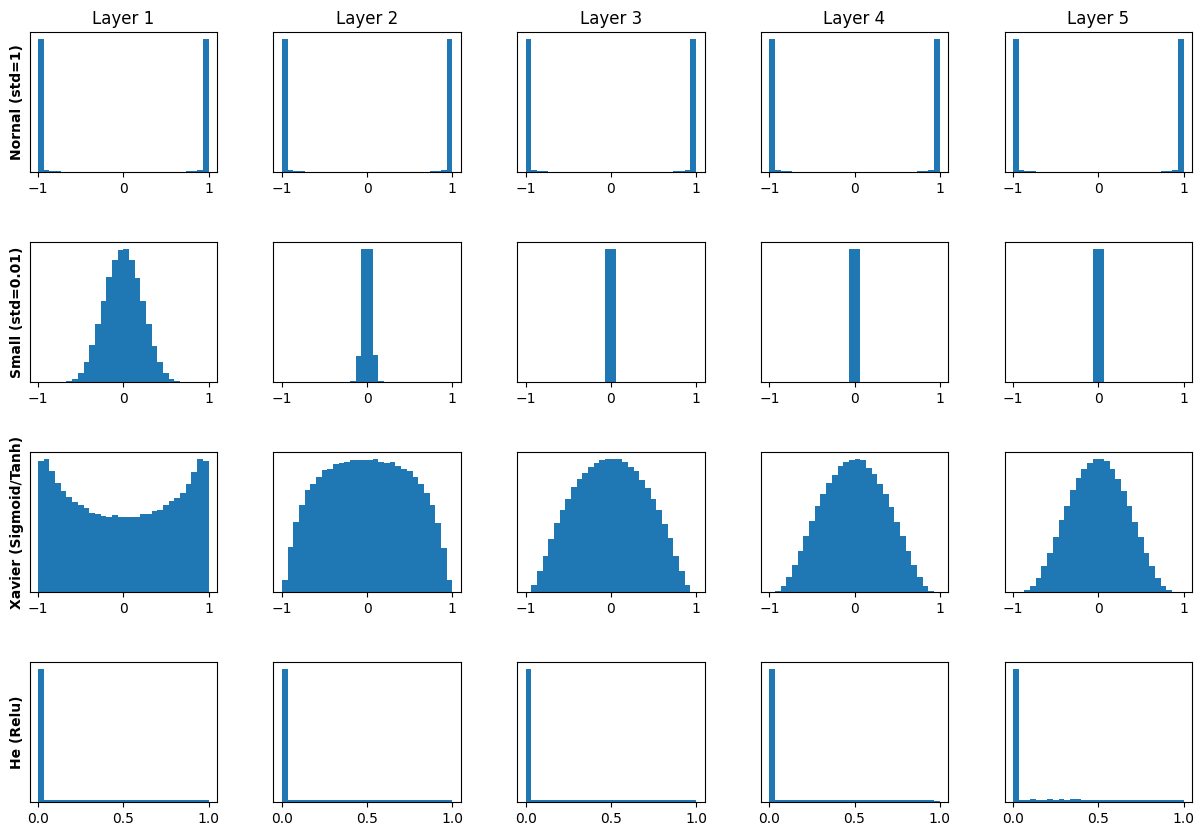

In [8]:
# 가중지 초기화 방법 비교
def visualize_initilaiztion():
    # 더미 데이터 생성
    x = torch.randn(1000, 512)

    init_methods = {
        'Nornal (std=1)' : (lambda m : nn.init.normal_(m.weight, std=1.0), torch.tanh, "Tanh"),
        'Small (std=0.01)' : (lambda m : nn.init.normal_(m.weight, std=0.01), torch.tanh, "Tanh"),
        'Xavier (Sigmoid/Tanh)': (lambda m : nn.init.xavier_normal_(m.weight), torch.tanh, "Tanh"),
        'He (Relu)': (lambda m : nn. init.kaiming_normal_(m.weight, nonlinearity='relu'), torch. relu, "ReLU")
    }

    fig, axes = plt.subplots(len(init_methods), 5, figsize=(15, 10))
    plt.subplots_adjust(hspace=0.5, wspace=0.3)

    for i, (name, (init_fn, act_fn, act_name)) in enumerate(init_methods.items()):
        curr_x = x
        for j in range(5): # 5개의 은닉층을 통과
            fc = nn.Linear(512, 512, bias=False)
            init_fn(fc) # 각 전략에 따른 초기화 적용
            curr_x = act_fn(fc(curr_x))

            data = curr_x.detach().numpy().flatten()
            axes[i, j].hist(data, bins=30, range=(-1, 1) if act_name == "Tanh" else (0, 1))
            if j == 0: axes[i, j].set_ylabel(name, fontsize=10, fontweight='bold')
            if i == 0: axes[i, j].set_title(f"Layer {j+1}")
            axes[i, j].set_yticks([])
    plt.show()

visualize_initilaiztion()


In [25]:
# ICS를 관찰하기 위한 깊은 신경망을 만든다.
class DeepNet(nn.Module):
    def __init__ (self, use_bn=False):
        super(DeepNet, self).__init__()
        self.use_bn = use_bn

        # 5개의 은닉층 정의 (EN을 적용한것과 적용하지 않은 것)
        self.layers = nn.ModuleList([nn.Linear(100, 100) for _ in range(5) ])
        if use_bn: self.bn_layers = nn.ModuleList([nn.BatchNorm1d(100) for _ in range(5)])

        self.activation = nn.Sigmoid( )

    def forward(self, x):
        activations = []
        for i in range(len(self. layers)):
            x = self.layers[i](x)
            if self.use_bn: x = self.bn_layers[i](x) # 배치 정규화 적용
            x = self.activation(x)
            activations.append(x.detach( ))

        return activations

In [27]:
# 데이터 순비하고 실행
input_data = torch.randn(1000, 100)

model_no_bn = DeepNet(use_bn=False)
model_with_bn = DeepNet(use_bn=True)

act_no_bn = model_no_bn(input_data)
act_with_bn = model_with_bn(input_data)

5 5
torch.Size([1000, 100])


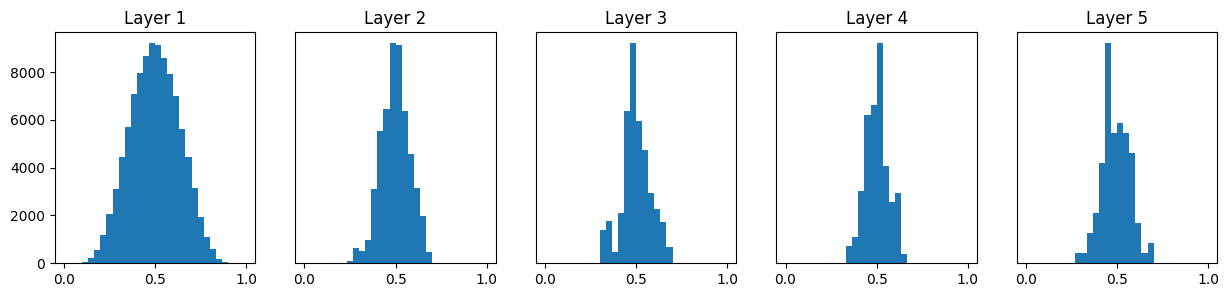

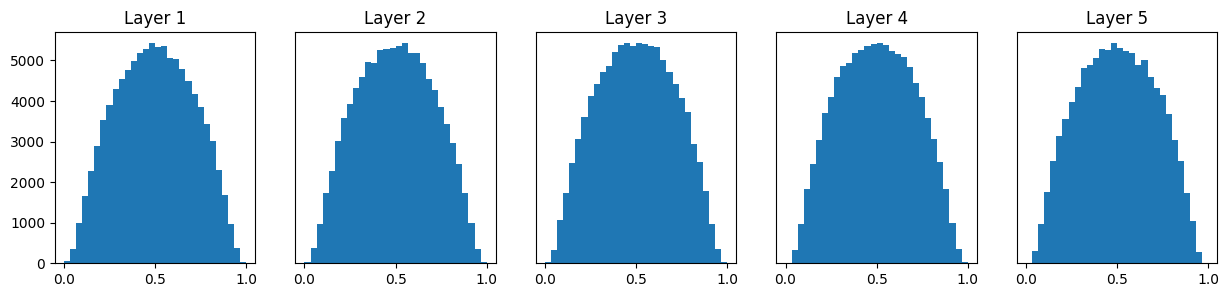

In [28]:
# 데이터 분포 시각화
def plot_activations(activation):
    plt.figure(figsize=(15, 3))
    for i, act in enumerate(activation):
        plt.subplot(1, 5, i+1)
        plt.title(f'Layer {i + 1}')
        plt.hist(act.flatten(), bins=30, range=(0, 1))
        if i != 0: plt.yticks([])
    plt.show()
print(len(act_no_bn), len(act_with_bn))
print(act_no_bn[0].shape)
plot_activations(act_no_bn)
plot_activations(act_with_bn)